# Notebook 2 — Advanced Exploratory Data Analysis

## 1. Setup & Imports

We load all required libraries, configure plot aesthetics, detect column names and types, and ingest both the **train** and **test** splits.

**Key loading decisions:**
- Train and test have been processed by base process pipeline, import as parquet. 
- The imported dataframes are the single source of truth.
- All features are float, for numerical, and category, for categorical.


In [2]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent  # or Path.cwd(), or a specific path
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, chi2_contingency
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
import math 

import logging
import shap 


from scipy import stats

import datetime
import json

from utils.utils_reproducibility import set_seed, get_folds
from utils.utils_fit_models import plot_shap_bar, plot_shap_beeswarm, plot_xgb_importance

from config import (
    GlobalConfig, global_cfg,          
    FeatureConfig, features,
    CompetitionConfig, DataConfig, XGBConfig, CVConfig,
    comp_cfg, data_cfg, xgb_cfg, cv_cfg,
    RAW_DIR, PROC_DIR, MODEL_DIR, SUB_DIR, ART_DIR,
    model_logger as log,
    pipeline_logger as pipe_log,
)
from config.env_cfg import make_exp_logger
import os
import joblib

# ── Plot aesthetics ────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

PALETTE_BIN = ['#20808D', '#A84B2F', '#FFC553']   # teal=low income, rust=high income
PALETTE_SEQ = ['#1B474D', '#20808D', '#BCE2E7', '#FFC553', '#A84B2F',
               '#944454', '#848456', '#6E522B']
print(f"pandas  {pd.__version__}  |  numpy  {np.__version__}  |  matplotlib  {matplotlib.__version__}  |  seaborn  {sns.__version__}")

# -----------------------------------------------------------------
def import_data(cfg:DataConfig, proc_dir:Path, target:str) \
        -> tuple[pd.DataFrame, pd.DataFrame, list[str], list[str]]:
    """
    Function to import train and test data. Load base files.
    
    """
    
    train_path = cfg.train_path(proc_dir)
    test_path  = cfg.test_path(proc_dir)

    df_train = pd.read_parquet(train_path)
    df_test  = pd.read_parquet(test_path)

    # Get feature types
    cats = [c for c in df_train.select_dtypes('category').columns if c != target]
    nums = [c for c in df_train.select_dtypes('float').columns if c != target]
    
    log.info(f"[load] {cfg.train_file}  shape={df_train.shape}")
    log.info(f"[load] {cfg.test_file}   shape={df_test.shape}")
    return df_train, df_test, cats, nums

df_train, df_test, cats, nums = import_data(data_cfg, PROC_DIR, features.target)

assert len(cats+nums) + 1 == df_train.shape[1], 'Data mismatch either df_train or cats and nums'

print(f'Train shape : {df_train.shape}')
print(f'Test shape  : {df_test.shape}')
print(f'Combined    : {df_train.shape[0] + df_test.shape[0]:,} rows, {len(cats+nums)} columns')
print(f'\nTarget labels (unique): {sorted(df_train[features.target].unique())}')
print(f'Categorical features: {cats}')
print(f'Numerical features: {nums}')


12:57:05  INFO      models        [load] s6e6_star_train_base_20260611.parquet  shape=(577347, 11)
12:57:05  INFO      models        [load] s6e6_star_test_base_20260611.parquet   shape=(247435, 10)


pandas  3.0.2  |  numpy  2.4.4  |  matplotlib  3.10.9  |  seaborn  0.13.2
Train shape : (577347, 11)
Test shape  : (247435, 10)
Combined    : 824,782 rows, 10 columns

Target labels (unique): ['GALAXY', 'QSO', 'STAR']
Categorical features: ['spectral_type', 'galaxy_population']
Numerical features: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']


## 2. Bivariate Analysis — Categorical Features vs Target

### What & Why
For each categorical feature we ask: *which categories are most associated with each target category*

We plot the **class** (proportion in each class category) per category rather than raw counts. Proportions remove the confounding effect of group size.


In [3]:
def plot_class_rate_by_category(
    df: pd.DataFrame,
    feature: str,
    target_col: str,
    target_class,
    ax: plt.Axes,
    top_n: int | None = None,
    title: str | None = None,
) -> None:
    """
    Bar chart of P(target == target_class | feature category), sorted descending.

    Parameters
    ----------
    df          : source DataFrame.
    feature     : categorical column name.
    target_col  : name of target column.
    target_class: specific class value to focus on (e.g. '>50K', 'mid', etc.).
    ax          : matplotlib Axes to draw on.
    top_n       : if given, keep only the top_n categories by sample count.
    title       : custom title; defaults to feature name + class label.
    """
    # Boolean indicator for membership in this class
    is_class = (df[target_col] == target_class).astype(float)

    grp = df.groupby(feature)[is_class.name if hasattr(is_class, 'name') else target_col]
    # groupby on feature, then use is_class via .mean() and .count()
    # easier: just recompute per-group manually:
    g = df.groupby(feature)
    rate = (g[target_col].apply(lambda s: (s == target_class).mean())
            .rename('rate'))
    count = g[target_col].size().rename('count')

    tbl = pd.concat([rate, count], axis=1).dropna()

    if top_n is not None:
        tbl = tbl.nlargest(top_n, 'count')

    tbl = tbl.sort_values('rate', ascending=False)
    overall_rate = (df[target_col] == target_class).mean()
    n_cats = len(tbl)

    cmap = plt.get_cmap('RdYlGn', n_cats)
    colors = cmap(np.linspace(0.15, 0.85, n_cats))

    bars = ax.bar(
        range(n_cats),
        tbl['rate'] * 100,
        color=colors,
        edgecolor='white',
        linewidth=0.6,
        zorder=3,
    )

    # Annotate count
    for bar, cnt in zip(bars, tbl['count']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'n={cnt:,}',
            ha='center',
            va='bottom',
            fontsize=6.5,
            color='#555555',
        )

    # Reference line at overall class prevalence
    ax.axhline(
        overall_rate * 100,
        color='#333333',
        lw=1.2,
        ls='--',
        zorder=2,
        label=f'Overall {target_class}: {overall_rate:.1%}',
    )

    ax.set_xticks(range(n_cats))
    ax.set_xticklabels(tbl.index, rotation=35, ha='right', fontsize=7.5)
    ax.set_ylabel(f'P({target_class} | {feature}) (%)', fontsize=9)

    if title is None:
        title = f"{feature.replace('_', ' ').title()} — class: {target_class}"
    ax.set_title(title, fontsize=10, fontweight='bold')

    ax.set_ylim(0, max(tbl['rate'].max() * 100 + 12, 35))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    ax.legend(loc='upper right', fontsize=7)
    ax.grid(axis='y', alpha=0.3, zorder=0)

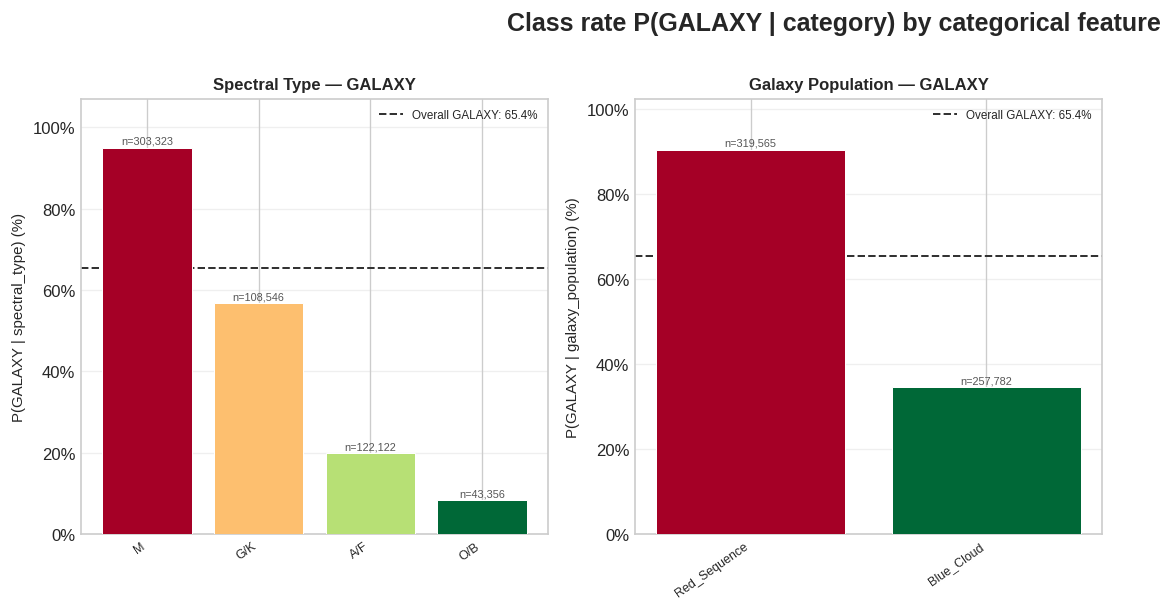

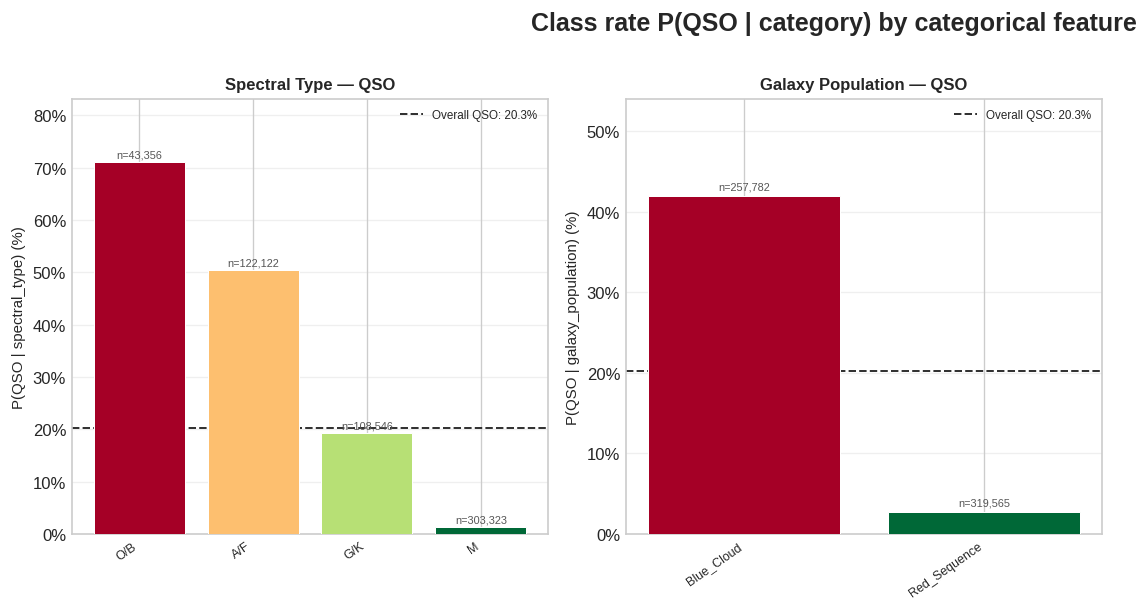

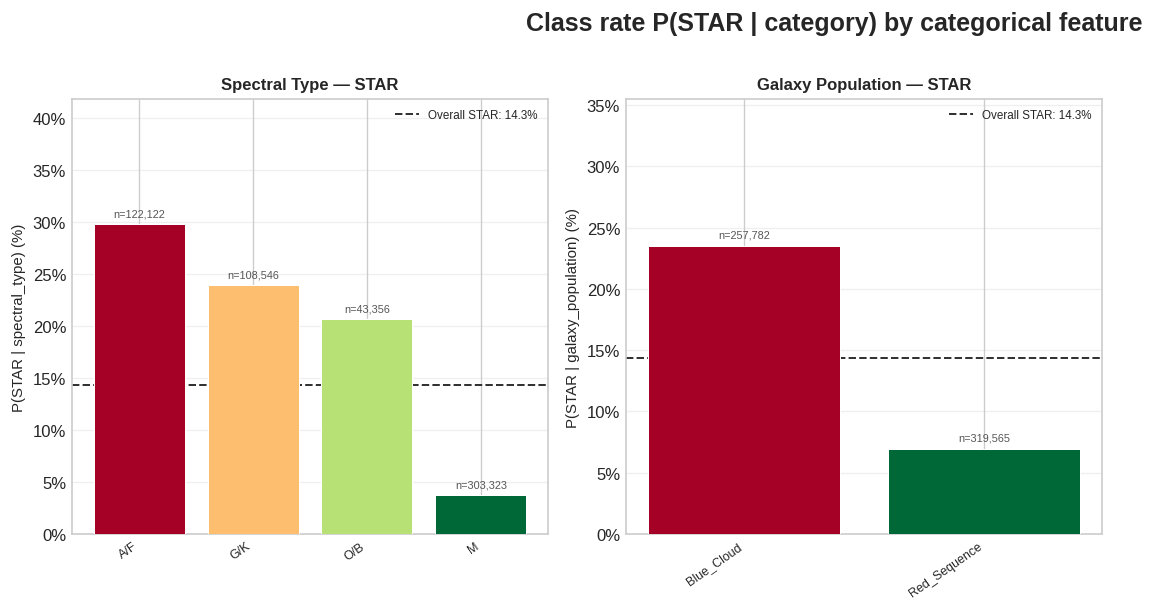

In [4]:
target_col = features.target
classes = df_train[target_col].cat.categories.tolist()  # or sorted(df[target_col].unique())

features_cfg = [
    ('spectral_type',      None, 'Spectral Type'),
    ('galaxy_population',      None, 'Galaxy Population'),
]

num_rows = math.ceil(len(cats)/3)
for target_class in classes:
    fig, axes = plt.subplots(num_rows, 3, figsize=(14,5))
    axes = axes.ravel()

    for idx, (feat, top_n, base_title) in enumerate(features_cfg):
        title = f"{base_title} — {target_class}"
        plot_class_rate_by_category(
            df=df_train,
            feature=feat,
            target_col=target_col,
            target_class=target_class,
            ax=axes[idx],
            top_n=top_n,
            title=title,
        )

    # Hide any unused subplot
    axes[-1].set_visible(False)

    fig.suptitle(
        f'Class rate P({target_class} | category) by categorical feature',
        fontsize=15,
        fontweight='bold',
        y=1.01,
    )
    plt.tight_layout()
    plt.show()

## 3. Bivariate Analysis — Numerical Features vs Target

### What & Why
For continuous features we want to understand not just the *means* across income classes, but the full *shape* of each distribution: spread, skew, and multimodality.

**Violin plots** combine a rotated kernel-density estimate (showing the shape of the distribution) with an embedded box plot (median, quartiles, whiskers). They reveal:
- **Separation** — how far apart the two income groups sit on the feature's scale. Wide separation → strong univariate signal.
- **Spread** — the width of the violin at each value. Narrow at top/bottom means few extreme values.
- **Bimodality** — multiple bumps indicate sub-populations.

We overlay individual data points (jitter, α=0.05) to show raw data density without overplotting.



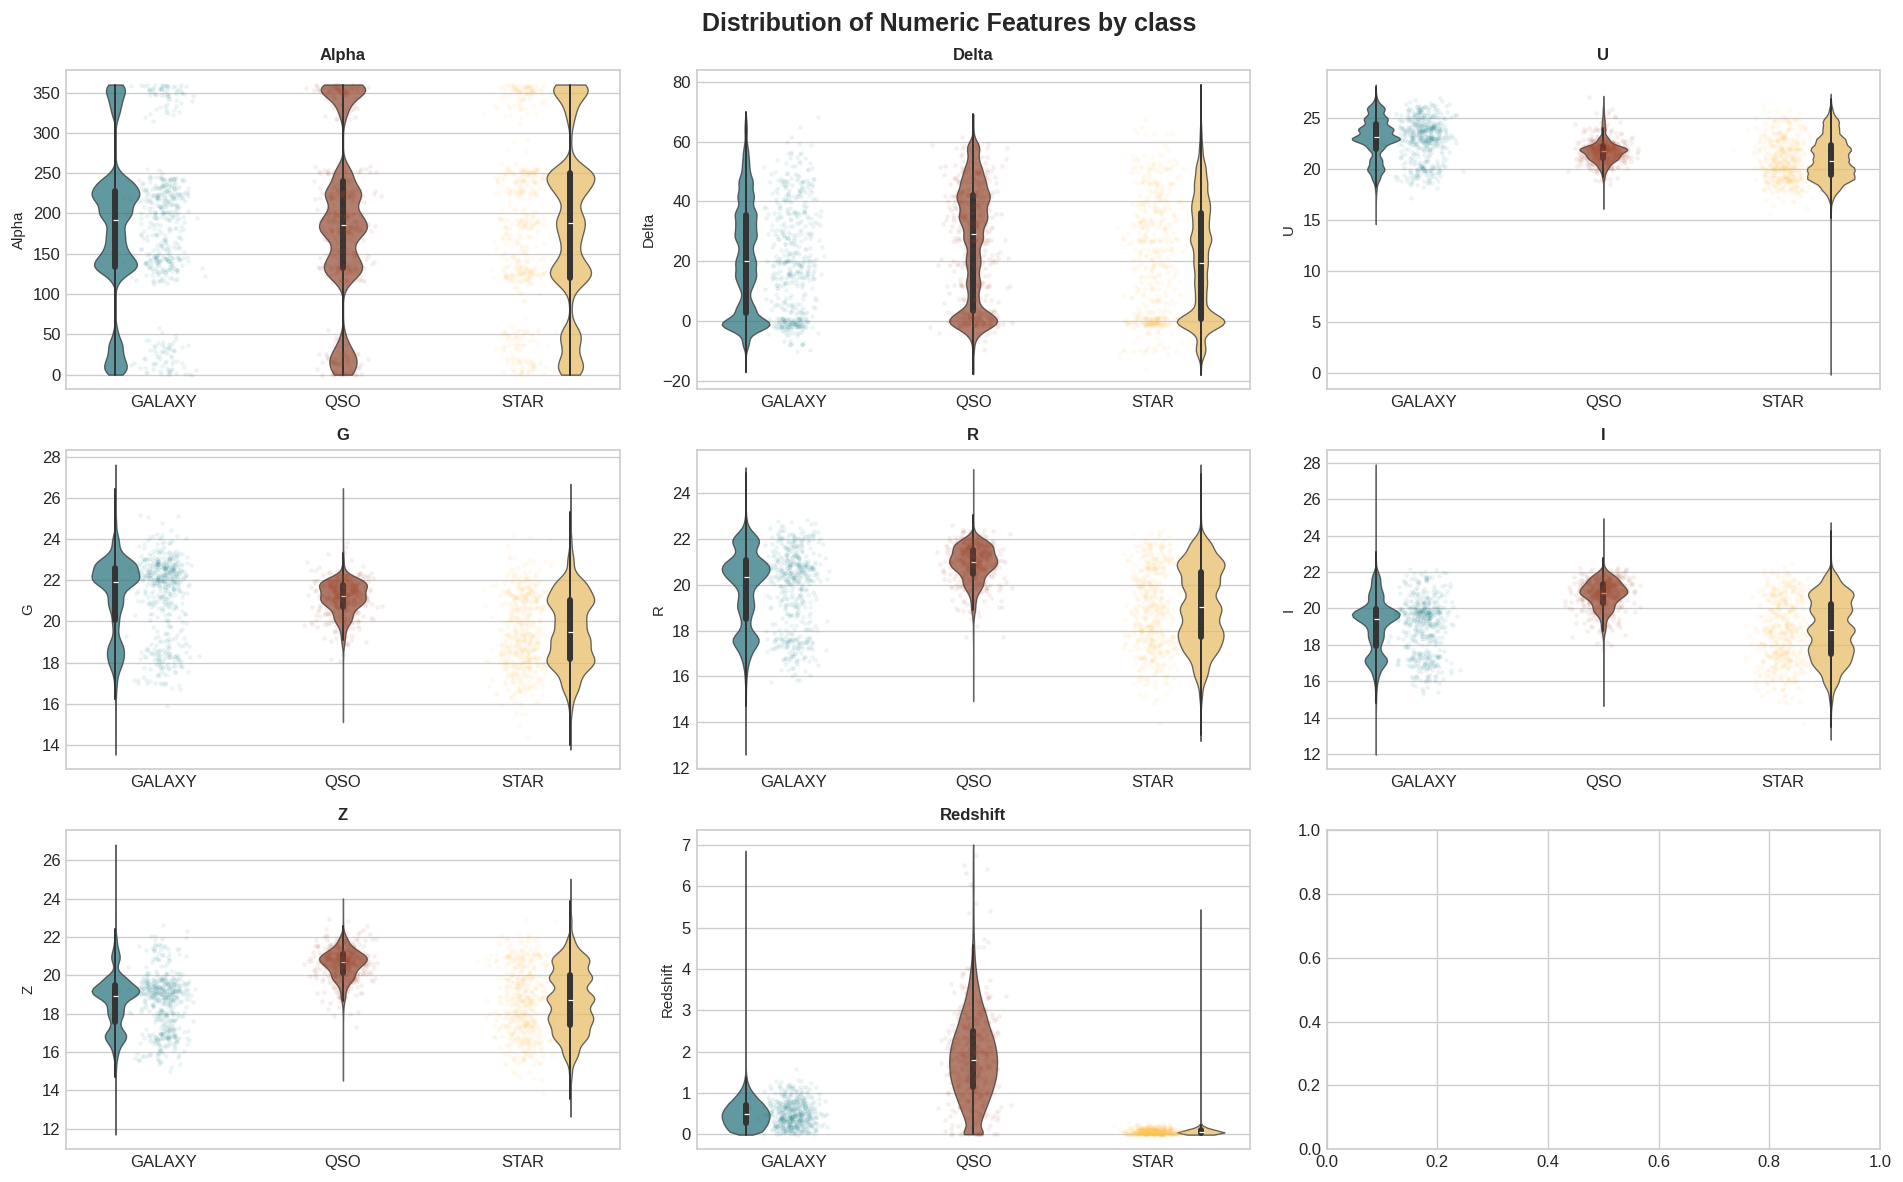

In [ ]:
def plot_violin_with_jitter(
    df: pd.DataFrame,
    feature: str,
    ax: plt.Axes,
    max_jitter: int = 500,
) -> None:
    """Side-by-side violin + box plot with jittered points and Mann-Whitney annotation.

    Parameters
    ----------
    df          : DataFrame with 'income' column (0/1).
    feature     : numeric column name.
    ax          : target Axes.
    max_jitter  : max points to jitter per class (performance).
    """
    target_dict = {i: cat for i, cat in enumerate(df[features.target].cat.categories)}
    plot_df = df[[features.target, feature]].dropna()
    #plot_df[features.target] = plot_df[features.target].map(target_dict)

    sns.violinplot(
        data=plot_df, x=features.target, y=feature, order=list(target_dict.values()),
        hue=features.target, legend=False,
        palette= {target_dict[i]:PALETTE_BIN[i] for i in range(len(target_dict))},
        inner='box', cut=0, linewidth=0.8, ax=ax, alpha=0.75
    )

    # Jitter overlay
    for i, label in enumerate(target_dict.values()):
        sub = plot_df[plot_df[features.target] == label][feature].dropna()
        if len(sub) > max_jitter:
            sub = sub.sample(max_jitter, random_state=42)
        jitter_x = np.random.normal(i, 0.07, size=len(sub))
        ax.scatter(jitter_x, sub, alpha=0.05, s=4,
                   color=PALETTE_BIN[i], zorder=3)

    ax.set_title(feature.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(feature.replace('_', ' ').title(), fontsize=9)

num_rows = math.ceil(len(nums) / 3)
fig, axes = plt.subplots(num_rows, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, feat in enumerate(nums):
    plot_violin_with_jitter(df_train, feat, axes[idx])

fig.suptitle(f'Distribution of Numeric Features by {features.target}', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Mutual Information Analysis

### What & Why
**Mutual Information (MI)** measures how much knowing a feature \(X\) reduces our uncertainty about the target \(Y\). Unlike Pearson correlation, MI captures *any* statistical dependency — linear or non-linear. It can also be used for numerical as well as categorical features.

> 📐 **Math Note — Mutual Information:**
>
> $$I(X; Y) = \sum_{x \in \mathcal{X}} \sum_{y \in \mathcal{Y}} p(x, y) \log \frac{p(x, y)}{p(x)\, p(y)}$$
>
> This is the Kullback-Leibler divergence $D_{KL}(p(X,Y) \| p(X)p(Y))$ — it equals zero if and only if $X$ and $Y$ are statistically independent, and increases as they become more dependent.
>
> **Relationship to entropy:** $I(X; Y) = H(Y) - H(Y | X)$ where $H(Y) = -\sum_y p(y) \log p(y)$ is the Shannon entropy of $Y$. MI is the reduction in entropy of $Y$ after observing $X$ — the information $X$ provides about $Y$.

> 🔍 **Deep Dive:** `sklearn.feature_selection.mutual_info_classif` estimates MI using a k-nearest-neighbour approach (Kraskov estimator) for continuous features, and plug-in estimation for discrete ones. It handles non-linear relationships but is sensitive to the number of nearest neighbours (default k=3). MI values are in *nats* (natural log) or *bits* (log base 2), but only relative rankings matter here.

> 💡 **Industry Practice:** MI-based feature selection often outperforms correlation-based selection in tree-ensemble pipelines because it measures the same kind of dependency the trees exploit.


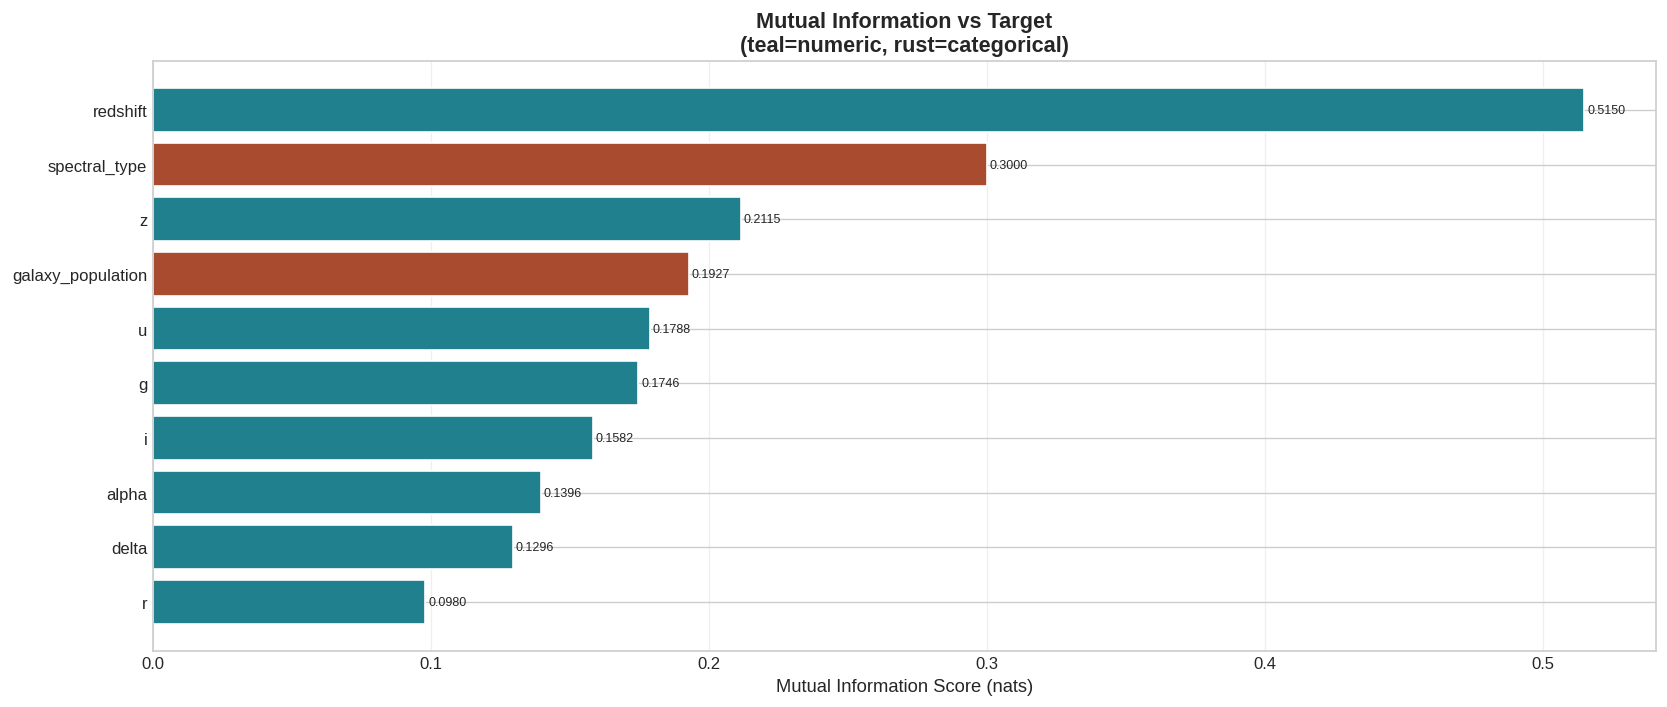


Note: MI captures non-linear dependencies


In [6]:
# Encode categoricals for MI computation
df_mi = df_train[nums + cats + [features.target]].dropna()

le = LabelEncoder()
df_enc = df_mi.copy()
for col in cats:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

X_all = df_enc.drop(columns=features.target)
y_all = df_enc[features.target]

# Compute MI for all features
mi_scores = mutual_info_classif(X_all, y_all,
                                discrete_features=[False] * len(nums)
                                               + [True]  * len(cats),
                                random_state=42)

mi_series = pd.Series(mi_scores, index=X_all.columns).sort_values(ascending=True)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 1, figsize=(14, 6))

# MI bar chart
colors_mi = [PALETTE_BIN[1] if c in cats else PALETTE_BIN[0]
             for c in mi_series.index]
axes.barh(mi_series.index, mi_series.values, color=colors_mi, edgecolor='white')
axes.set_xlabel('Mutual Information Score (nats)')
axes.set_title('Mutual Information vs Target\n(teal=numeric, rust=categorical)',
                  fontweight='bold')
axes.grid(axis='x', alpha=0.3)
for i, (idx, val) in enumerate(mi_series.items()):
    axes.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=7.5)


plt.tight_layout()
plt.show()
print("\nNote: MI captures non-linear dependencies")


## 5. Feature Interactions

### What & Why
**Interaction effects** occur when the relationship between a feature and the target *depends* on another feature. For example, additional education might predict higher income strongly for men but less so for women — an education × sex interaction. Univariate analysis misses this completely. Interaction can occure between different type of data; numxnum, numxcat, catxcat are all legit.

Identifying interactions matters for:
- **Feature engineering** — interaction terms (e.g. `spectral_type × galaxy_population`) can dramatically improve linear models. And help speed up GBDT or NN-models.
- **Model selection** — decision trees and random forests capture interactions automatically; linear models do not.
- **Fairness** — disparities often manifest at the intersection of demographic features, not within a single dimension.

> 💡 **Industry Practice:** Heatmaps (pivot tables of mean target by two features) are the fastest way to scan for interactions. Any large contrast between cells indicates a potential interaction worth modelling explicitly.

> 🔍 **Deep Dive:** Two features \(A\) and \(B\) interact with respect to target \(Y\) when $E[Y \mid A = a, B = b] \neq f(a) + g(b)$ for some functions \(f\) and \(g\). If the effect were purely additive we could model it with two separate terms; interaction requires a product term $a \cdot b$ (or a non-parametric joint term in tree-based models).

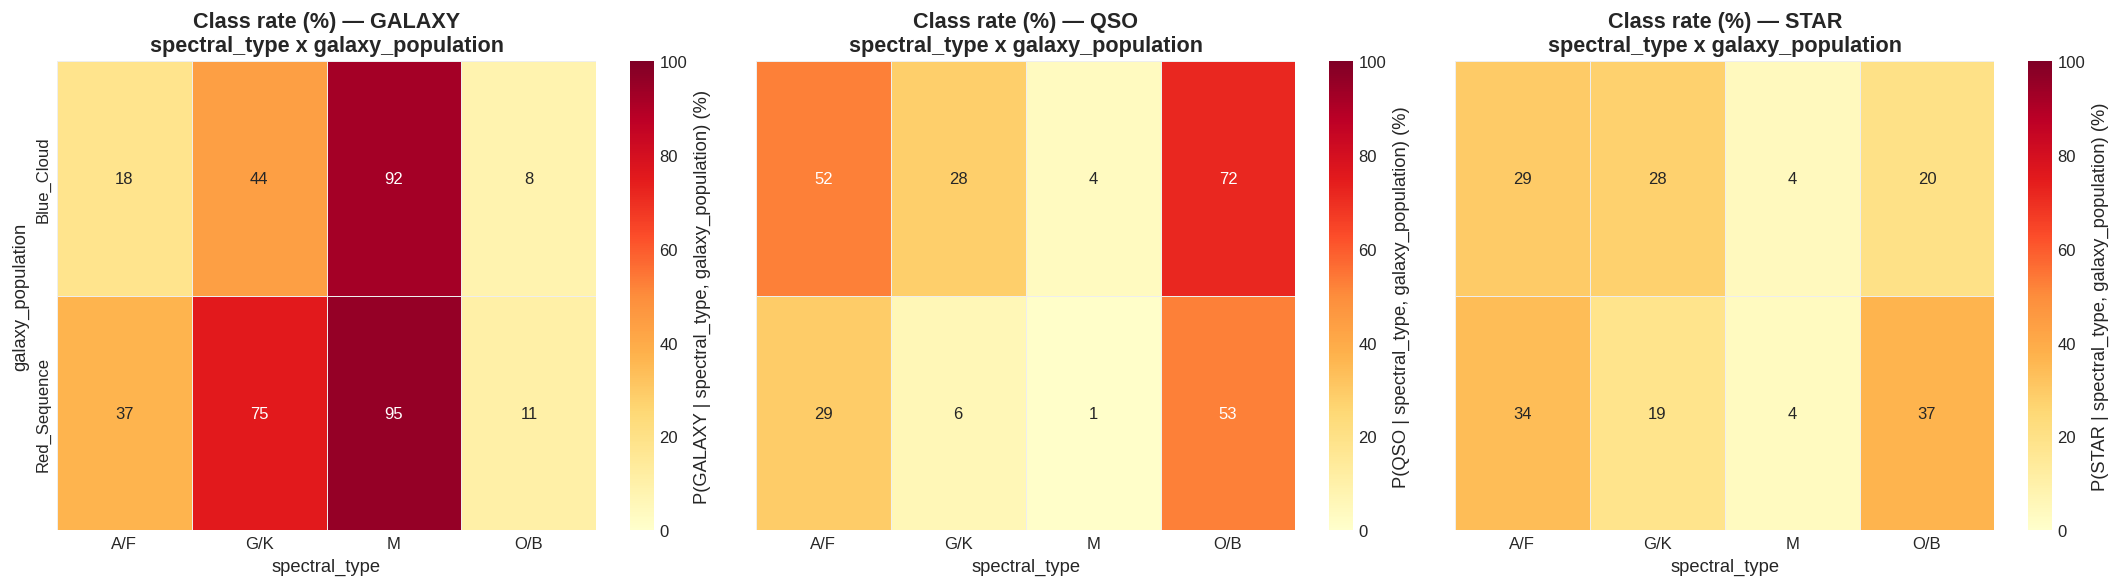

In [ ]:

def cat_cat_heatmap(df:pd.DataFrame, feature1:str, feature2:str):
    """ Plot feature interaction between two cat features and a cat target.
    
    """
    classes = df[features.target].cat.categories.tolist()  # or sorted unique values

    n_classes = len(classes)
    fig, axes = plt.subplots(1, n_classes, figsize=(6 * n_classes, 5), sharey=True)

    if n_classes == 1:
        axes = [axes]  # degenerate case

    for idx, cls in enumerate(classes):
        # 3. Compute P(target == cls | feat1, feat2)
        mask = (df_train[features.target] == cls).astype(float)

        pivot_cls = (
            df_train.assign(target_is_cls=mask)
            .groupby([feature1, feature2])['target_is_cls']
            .mean()
            .unstack(feature1)
            #.reindex(columns=edu_present)
            #.reindex(index=age_labels)
        )

        ax = axes[idx]
        sns.heatmap(
            pivot_cls * 100,
            annot=True,
            fmt='.0f',
            cmap='YlOrRd',
            linewidths=0.4,
            linecolor='#eeeeee',
            cbar_kws={f'label': f'P({cls} | {feature1}, {feature2}) (%)'},
            ax=ax,
            vmin=0,
            vmax=100,  # same scale across classes
        )
        ax.set_title(
            f'Class rate (%) — {cls}\n{feature1} x {feature2}',
            fontsize=13,
            fontweight='bold',
        )
        ax.set_xlabel(feature1)
        if idx == 0:
            ax.set_ylabel(feature2)
        else:
            ax.set_ylabel('')

    plt.tight_layout()
    plt.show()
    return 

cat_cat_heatmap(df_train, 'spectral_type', 'galaxy_population')

In [8]:
# Function for feature interaction num x cat features
def num_cat_heatmap(df_in:pd.DataFrame, feat1_num:str, feat2_cat:str, feat_bins:list, feat_labels:list):
    """ Plot interaction heatmap num, cat features, cat target.
    
    """
    df = df_in.copy()
    df[f'{feat1_num}_bucket'] = pd.cut(df[feat1_num], bins=feat_bins,
                            labels=feat_labels, right=False)

    target_col = features.target
    classes = df[target_col].cat.categories.tolist()  # or sorted unique values

    n_classes = len(classes)
    fig, axes = plt.subplots(1, n_classes, figsize=(6 * n_classes, 5), sharey=True)

    if n_classes == 1:
        axes = [axes]  # degenerate case

    for idx, cls in enumerate(classes):
        # 3. Compute P(target == cls | age_bucket, education)
        mask = (df[target_col] == cls).astype(float)

        pivot_cls = (
            df.assign(target_is_cls=mask)
            .groupby([feat2_cat, f'{feat1_num}_bucket'])['target_is_cls']
            .mean()
            .unstack(f'{feat1_num}_bucket')
            .reindex(columns=feat_labels)
            #   .reindex(index=feat_labels)
        )

        ax = axes[idx]
        sns.heatmap(
            pivot_cls * 100,
            annot=True,
            fmt='.0f',
            cmap='YlOrRd',
            linewidths=0.4,
            linecolor='#eeeeee',
            cbar_kws={'label': f'P({cls} | {feat1_num}, {feat2_cat}) (%)'},
            ax=ax,
            vmin=0,
            vmax=100,  # same scale across classes
        )
        ax.set_title(
            f'Class rate (%) — {cls}\n{feat1_num} × {feat2_cat}',
            fontsize=13,
            fontweight='bold',
        )
        ax.set_xlabel(f'{feat1_num}')
        if idx == 0:
            ax.set_ylabel(f'{feat2_cat}')
        else:
            ax.set_ylabel('')

    plt.tight_layout()
    plt.show()
    return

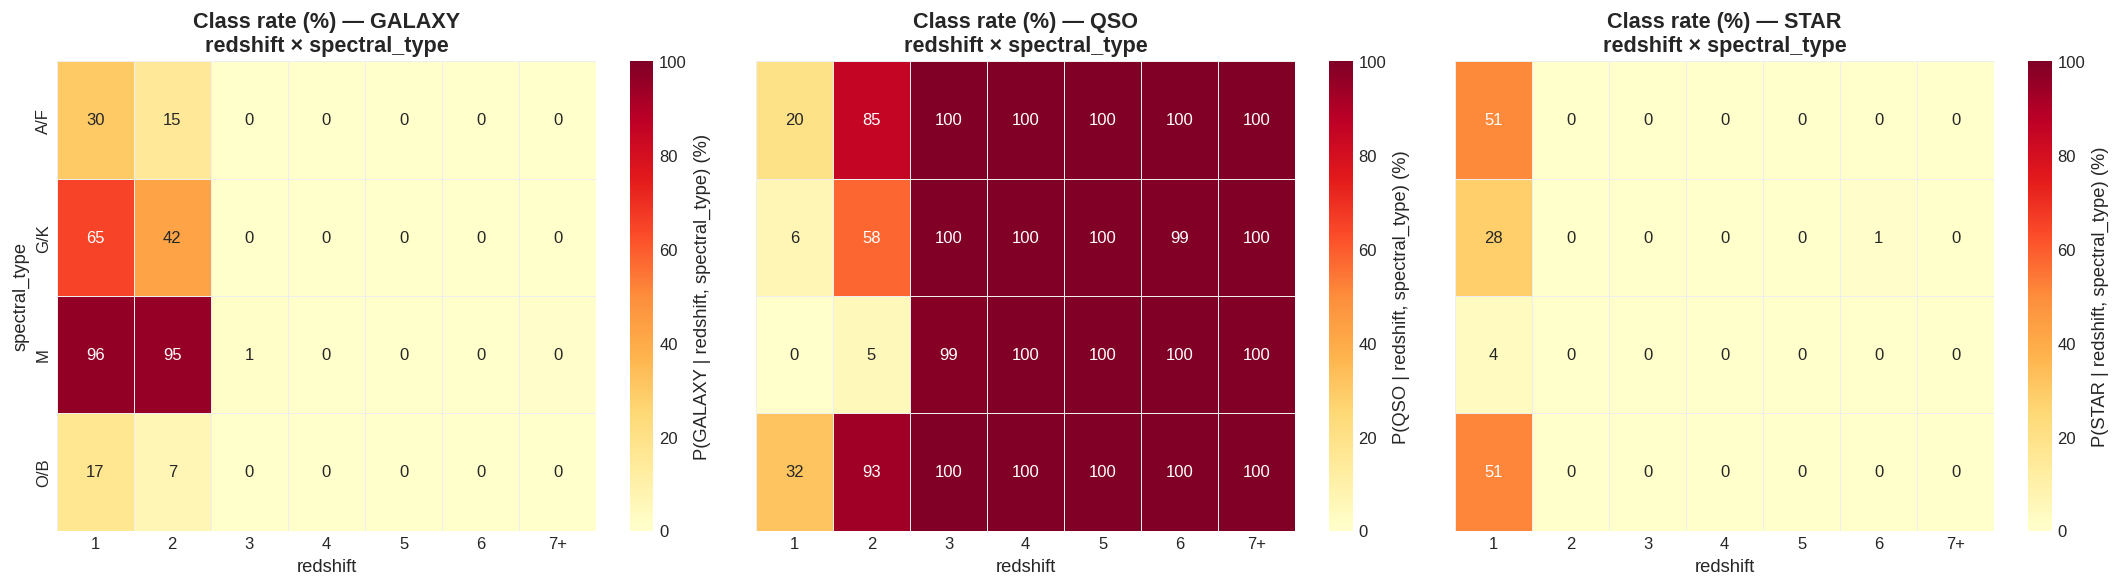

In [9]:
# redshift x spectral_type
feat_bins   = [0.,1.,2.,3.,4.,5.,6.,100.]
feat_labels = ['1', '2', '3', '4', '5', '6', '7+']
num_cat_heatmap(df_train, 'redshift', 'spectral_type', feat_bins, feat_labels)


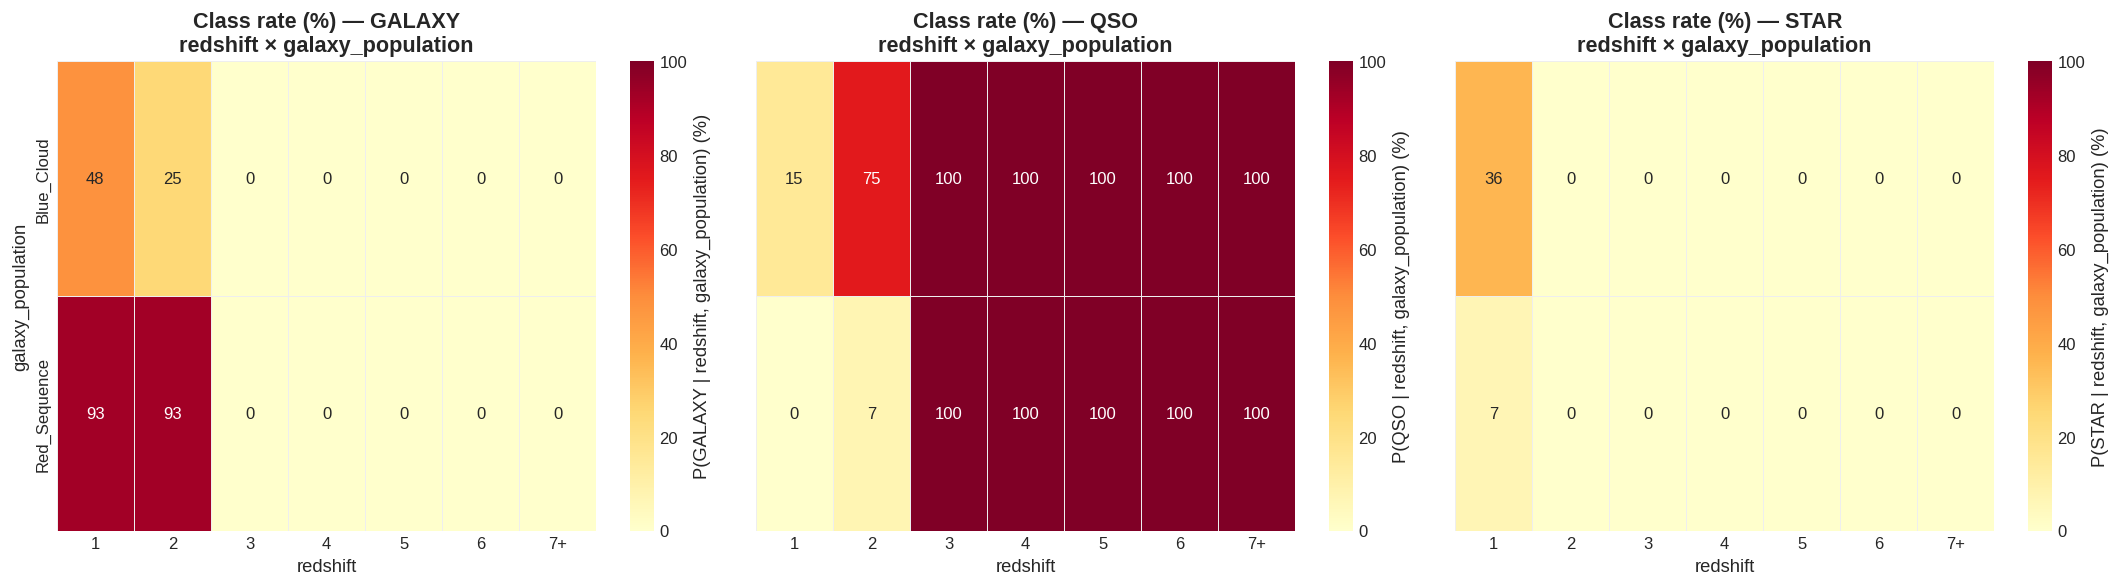

In [10]:
# redshift x galaxy_population
feat_bins   = [0.,1.,2.,3.,4.,5.,6.,100.]
feat_labels = ['1', '2', '3', '4', '5', '6', '7+']
num_cat_heatmap(df_train, 'redshift', 'galaxy_population', feat_bins, feat_labels)

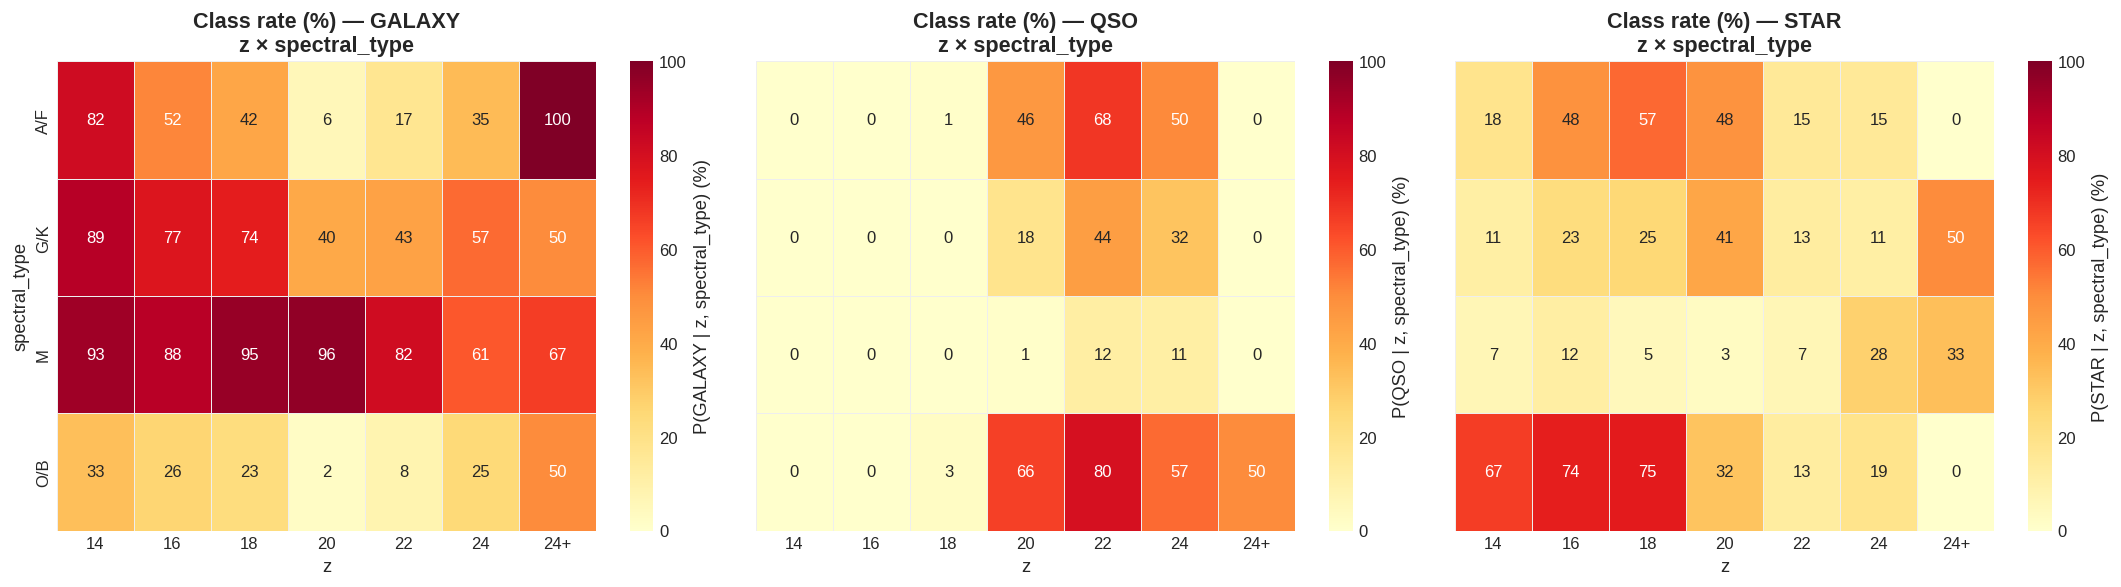

In [11]:
# redshift x galaxy_population
feat1_bins   = [0., 14., 16., 18., 20., 22., 24., 100.]
feat1_labels = ['14', '16', '18', '20', '22', '24', '24+']
num_cat_heatmap(df_train, 'z', 'spectral_type', feat1_bins, feat1_labels)

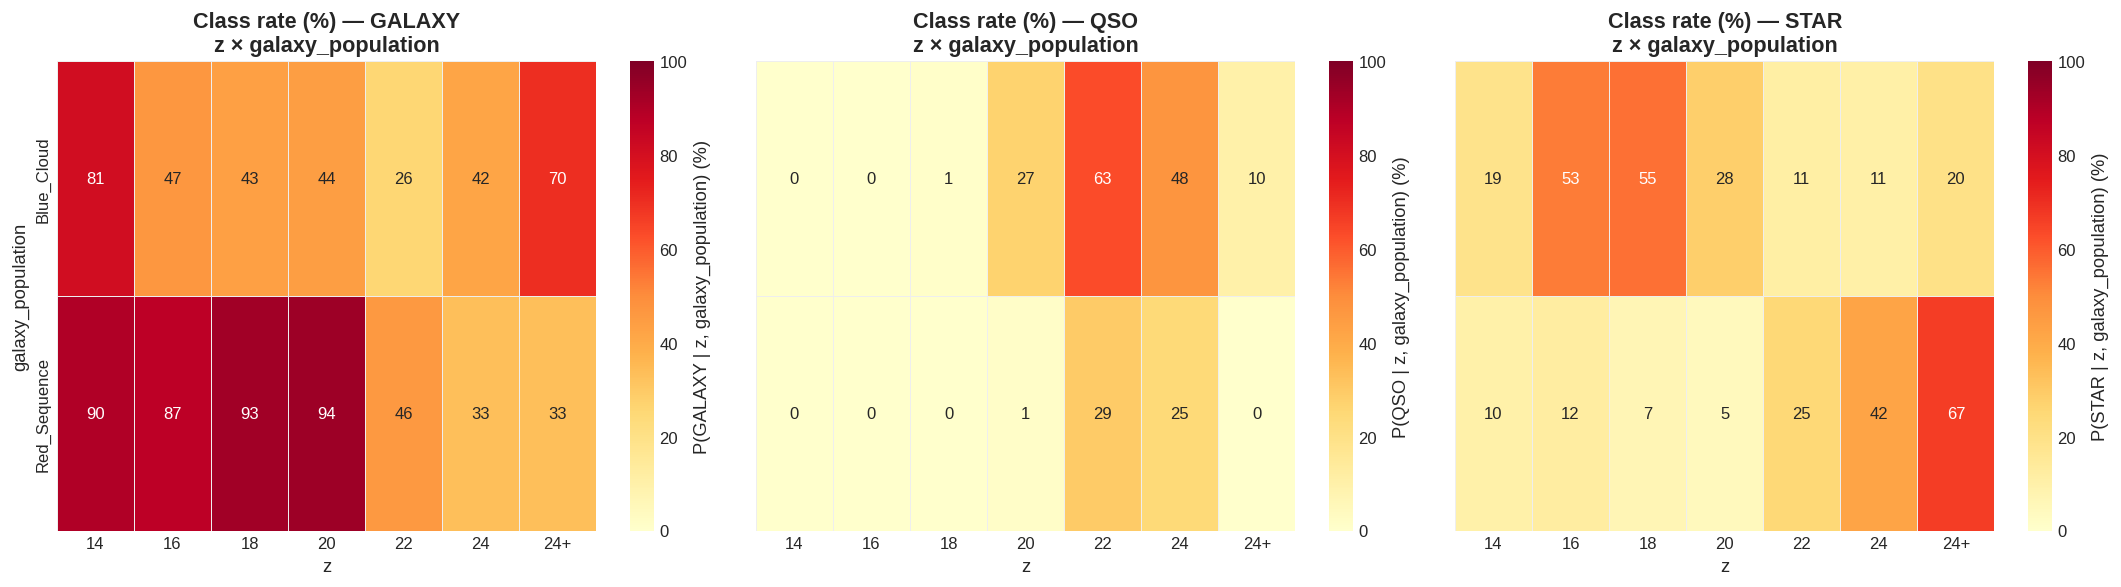

In [12]:
# z x galaxy_population
feat1_bins   = [0., 14., 16., 18., 20., 22., 24., 100.]
feat1_labels = ['14', '16', '18', '20', '22', '24', '24+']
num_cat_heatmap(df_train, 'z', 'galaxy_population', feat1_bins, feat1_labels)

In [13]:
# Function for feature interaction num x cat features
def num_num_heatmap(df_in:pd.DataFrame, feat1_num:str, feat2_num:str, feat1_bins:list, feat1_labels:list, feat2_bins:list, feat2_labels:list):
    """ Plot interaction heatmap num, cat features, cat target.
    
    """
    df = df_in.copy()
    df[f'{feat1_num}_bucket'] = pd.cut(df[feat1_num], bins=feat1_bins,
                            labels=feat1_labels, right=False)
    df[f'{feat2_num}_bucket'] = pd.cut(df[feat2_num], bins=feat2_bins,
                            labels=feat2_labels, right=False)
    
    target_col = features.target
    classes = df[target_col].cat.categories.tolist()  # or sorted unique values

    n_classes = len(classes)
    fig, axes = plt.subplots(1, n_classes, figsize=(6 * n_classes, 5), sharey=True)

    if n_classes == 1:
        axes = [axes]  # degenerate case

    for idx, cls in enumerate(classes):
        # 3. Compute P(target == cls | age_bucket, education)
        mask = (df[target_col] == cls).astype(float)

        pivot_cls = (
            df.assign(target_is_cls=mask)
            .groupby([f'{feat1_num}_bucket', f'{feat2_num}_bucket'])['target_is_cls']
            .mean()
            .unstack(f'{feat2_num}_bucket')
            .reindex(columns=feat2_labels)
            .reindex(index=feat1_labels)
        )

        ax = axes[idx]
        sns.heatmap(
            pivot_cls * 100,
            annot=True,
            fmt='.0f',
            cmap='YlOrRd',
            linewidths=0.4,
            linecolor='#eeeeee',
            cbar_kws={'label': f'P({cls} | {feat1_num}, {feat2_num}) (%)'},
            ax=ax,
            vmin=0,
            vmax=100,  # same scale across classes
        )
        ax.set_title(
            f'Class rate (%) — {cls}\n{feat1_num} × {feat2_num}',
            fontsize=13,
            fontweight='bold',
        )
        ax.set_xlabel(f'{feat2_num}')
        if idx == 0:
            ax.set_ylabel(f'{feat1_num}')
        else:
            ax.set_ylabel('')

    plt.tight_layout()
    plt.show()
    return

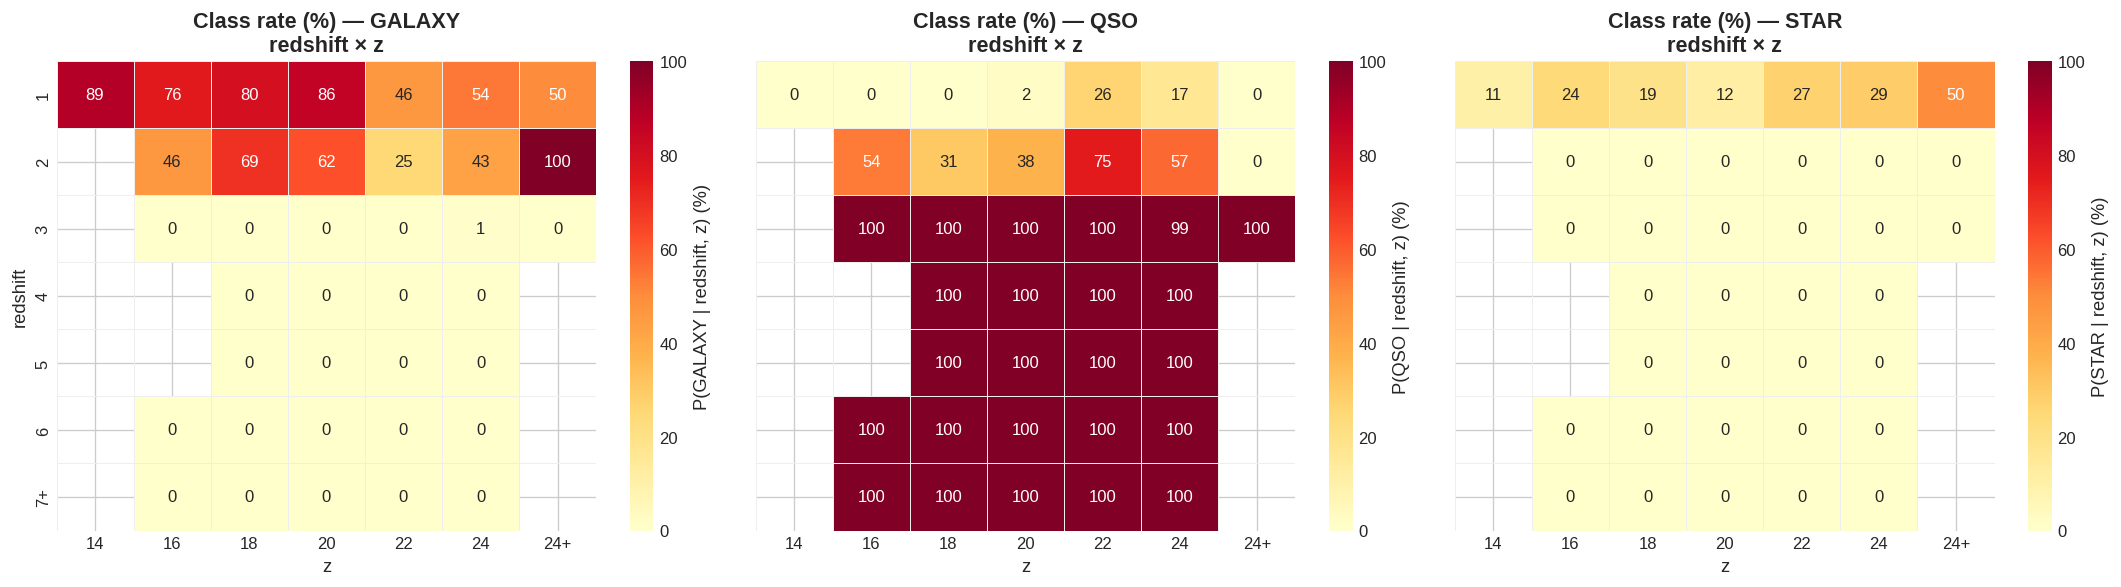

In [14]:
# redshift x galaxy_population
feat1_bins   = [0.,1.,2.,3.,4.,5.,6.,100.]
feat1_labels = ['1', '2', '3', '4', '5', '6', '7+']
feat2_bins   = [0., 14., 16., 18., 20., 22., 24., 100.]
feat2_labels = ['14', '16', '18', '20', '22', '24', '24+']
num_num_heatmap(df_train, 'redshift', 'z', feat1_bins, feat1_labels, feat2_bins, feat2_labels)

## 6. Outlier Analysis

### What & Why
An **outlier** is a data point that is far from the bulk of the distribution. Outliers matter for two reasons:
1. **Data quality** — Outliers may indicate data-entry errors (e.g. `age = 999`).
2. **Legitimate extreme values** — In economic data, a capital gain of \$99,999 is real and meaningful; it should not be removed.

### Detection Methods

| Method | Definition | Strengths | Weaknesses |
|---|---|---|---|
| **IQR** | Below $(Q1 - 1.5\text{IQR})$ or above $(Q3 + 1.5\text{IQR})$ | Simple, robust | Assumes unimodal distribution |
| **Z-score** | $(\|z\| > 3)$ where $(z = \frac{x - \mu}{\sigma})$ | Standard, well-known | Sensitive to the mean/std being skewed by outliers themselves |
| **Isolation Forest** | Anomaly score from random tree ensemble | Multivariate, non-parametric | Requires tuning; less interpretable |

|
> 📐 **Math Note — IQR Method:**
> $$\text{Lower fence} = Q_1 - 1.5 \cdot \text{IQR}, \quad \text{Upper fence} = Q_3 + 1.5 \cdot \text{IQR}$$
> where $(\text{IQR} = Q_3 - Q_1)$. This corresponds roughly to 2.7 standard deviations from the mean for normally distributed data.

> 💡 **Industry Practice:** For capital_gain and capital_loss — where zeros dominate and non-zero values form a separate sub-population — treat the two sub-populations separately. Remove outliers only after understanding *why* they exist.


In [15]:
from scipy import stats

def iqr_outliers(series: pd.Series) -> pd.Series:
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)

def zscore_outliers(series: pd.Series, threshold: float = 3.0) -> pd.Series:
    z = np.abs(stats.zscore(series.dropna()))
    mask = pd.Series(False, index=series.index)
    mask.loc[series.dropna().index] = z > threshold
    return mask

target_col = features.target

outlier_summary = []
for feat in nums:
    s = df_train[feat]
    iqr_mask = iqr_outliers(s)
    z_mask   = zscore_outliers(s)
    overlap  = (iqr_mask & z_mask).sum()

    # Class distributions for outliers vs non-outliers
    tgt_out   = df_train.loc[iqr_mask, target_col]
    tgt_non   = df_train.loc[~iqr_mask, target_col]

    # Percentages per class (as dicts)
    dist_out = (tgt_out.value_counts(normalize=True) * 100).round(1).to_dict()
    dist_non = (tgt_non.value_counts(normalize=True) * 100).round(1).to_dict()

    outlier_summary.append({
        "Feature"        : feat,
        "IQR outliers"   : int(iqr_mask.sum()),
        "Z>3 outliers"   : int(z_mask.sum()),
        "Both methods"   : int(overlap),
        "IQR class dist": dist_out,
        "Non class dist": dist_non,
    })

out_df = pd.DataFrame(outlier_summary)
print("Outlier Summary:")
print(out_df.to_string(index=False))

Outlier Summary:
 Feature  IQR outliers  Z>3 outliers  Both methods                             IQR class dist                              Non class dist
   alpha             0             0             0   {'GALAXY': nan, 'QSO': nan, 'STAR': nan} {'GALAXY': 65.4, 'QSO': 20.3, 'STAR': 14.3}
   delta             0             1             0   {'GALAXY': nan, 'QSO': nan, 'STAR': nan} {'GALAXY': 65.4, 'QSO': 20.3, 'STAR': 14.3}
       u           315           157           157 {'STAR': 50.2, 'GALAXY': 48.9, 'QSO': 1.0} {'GALAXY': 65.4, 'QSO': 20.3, 'STAR': 14.3}
       g          2806           796           796 {'GALAXY': 50.5, 'STAR': 49.3, 'QSO': 0.3} {'GALAXY': 65.5, 'QSO': 20.4, 'STAR': 14.2}
       r          1677           905           905 {'GALAXY': 63.4, 'STAR': 36.0, 'QSO': 0.6} {'GALAXY': 65.4, 'QSO': 20.3, 'STAR': 14.3}
       i          1277           784           784 {'GALAXY': 73.8, 'STAR': 25.3, 'QSO': 0.9} {'GALAXY': 65.4, 'QSO': 20.3, 'STAR': 14.3}
       z         

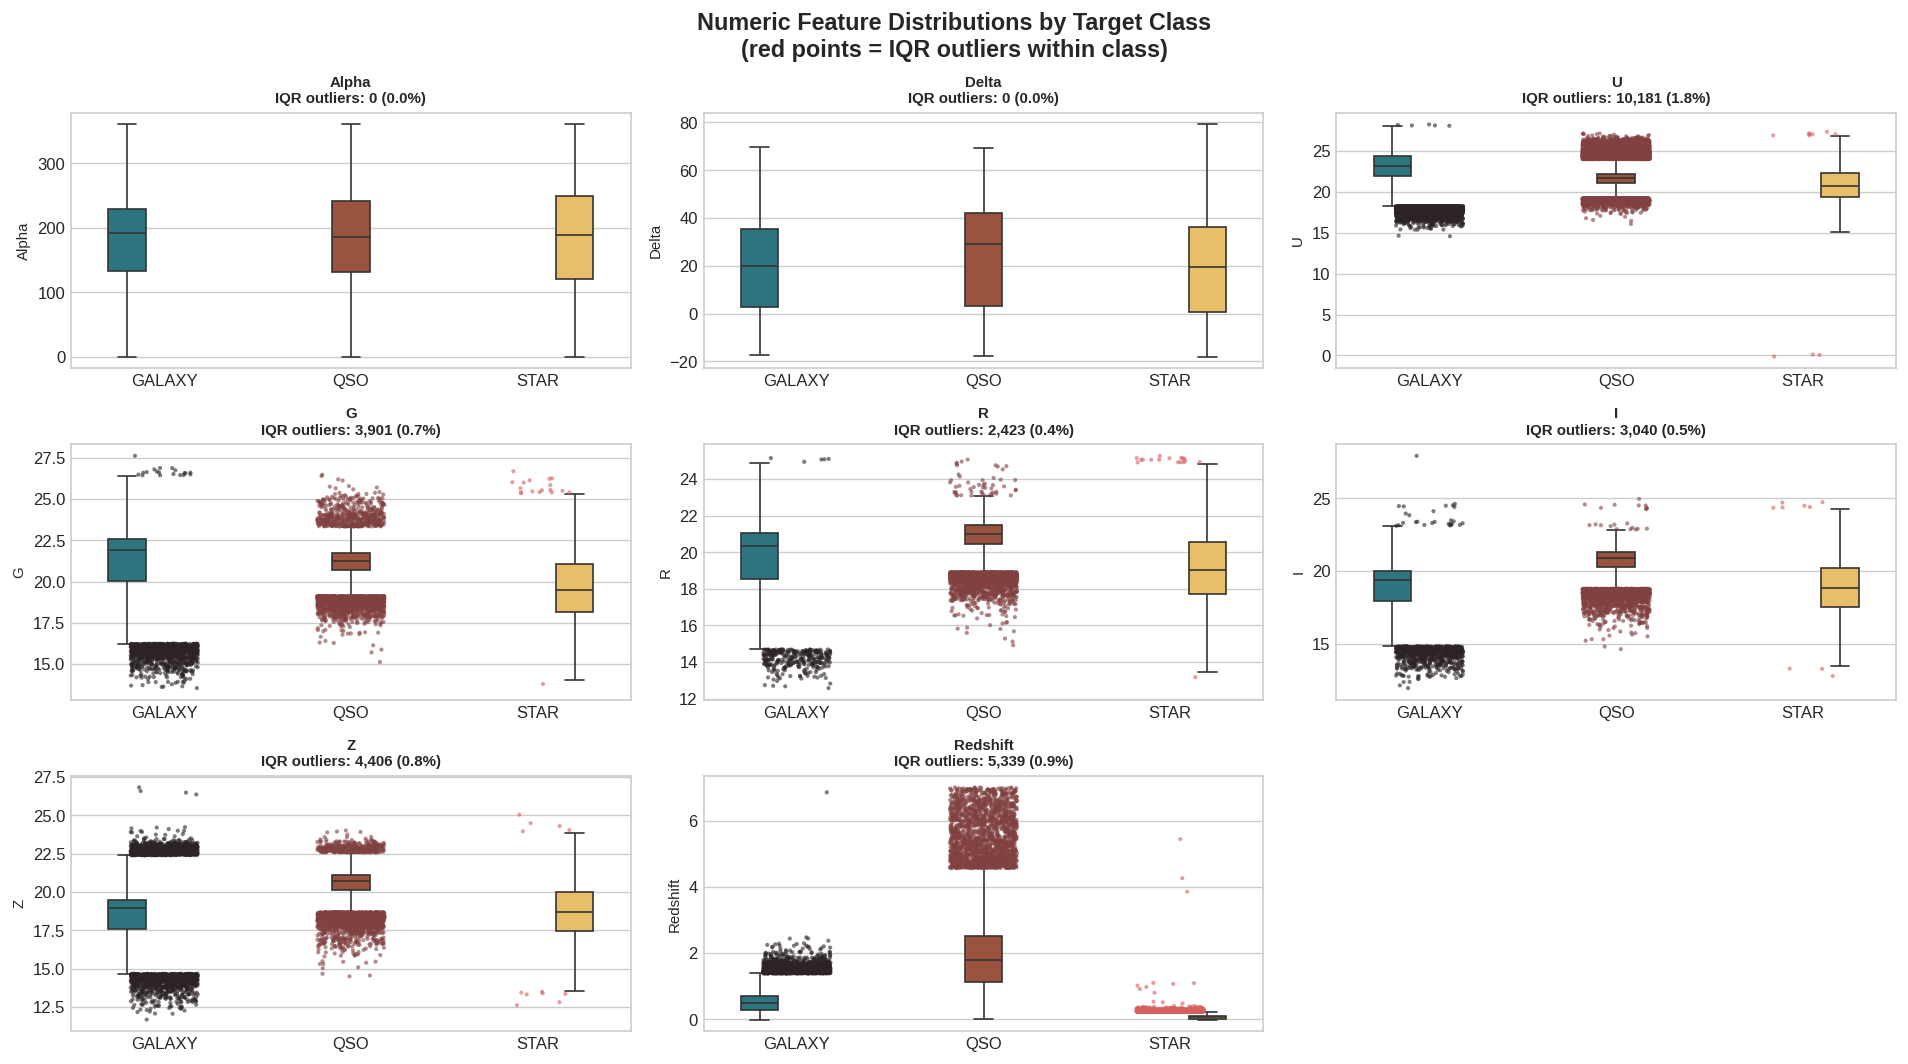

In [ ]:

def iqr_outliers(series: pd.Series) -> pd.Series:
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)

target_col = features.target
target_levels = df_train[target_col].cat.categories.tolist()

fig, axes = plt.subplots(3, 3, figsize=(16, 9))
axes = axes.ravel()

for idx, feat in enumerate(nums):
    ax = axes[idx]

    plot_df = df_train[[feat, target_col]].dropna().copy()

    # Compute outliers within each target class, not globally
    plot_df["is_outlier"] = (
        plot_df.groupby(target_col, observed=False)[feat]
        .transform(lambda s: iqr_outliers(s).astype(bool))
    )

    # Main boxplot by class
    sns.boxplot(
        data=plot_df,
        x=target_col,
        y=feat,
        hue=target_col,
        legend=False,
        order=target_levels,
        palette=PALETTE_BIN[:len(target_levels)],
        showfliers=False,
        width=0.6,
        linewidth=1,
        ax=ax,
    )


    # Highlight outliers
    sns.stripplot(
        data=plot_df.loc[plot_df["is_outlier"]],
        x=target_col,
        y=feat,
        hue=target_col,
        legend=False,
        order=target_levels,
        palette='dark:#D65F5F',
        alpha=0.6,
        size=2.5,
        jitter=0.18,
        ax=ax,
    )

    n_out = int(plot_df["is_outlier"].sum())
    p_out = plot_df["is_outlier"].mean()

    ax.set_title(
        f'{feat.replace("_"," ").title()}\nIQR outliers: {n_out:,} ({p_out:.1%})',
        fontweight='bold',
        fontsize=9
    )
    ax.set_xlabel("")
    ax.set_ylabel(feat.replace("_", " ").title(), fontsize=9)

# Hide unused axes if needed
for j in range(len(nums), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "Numeric Feature Distributions by Target Class\n(red points = IQR outliers within class)",
    fontsize=14,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

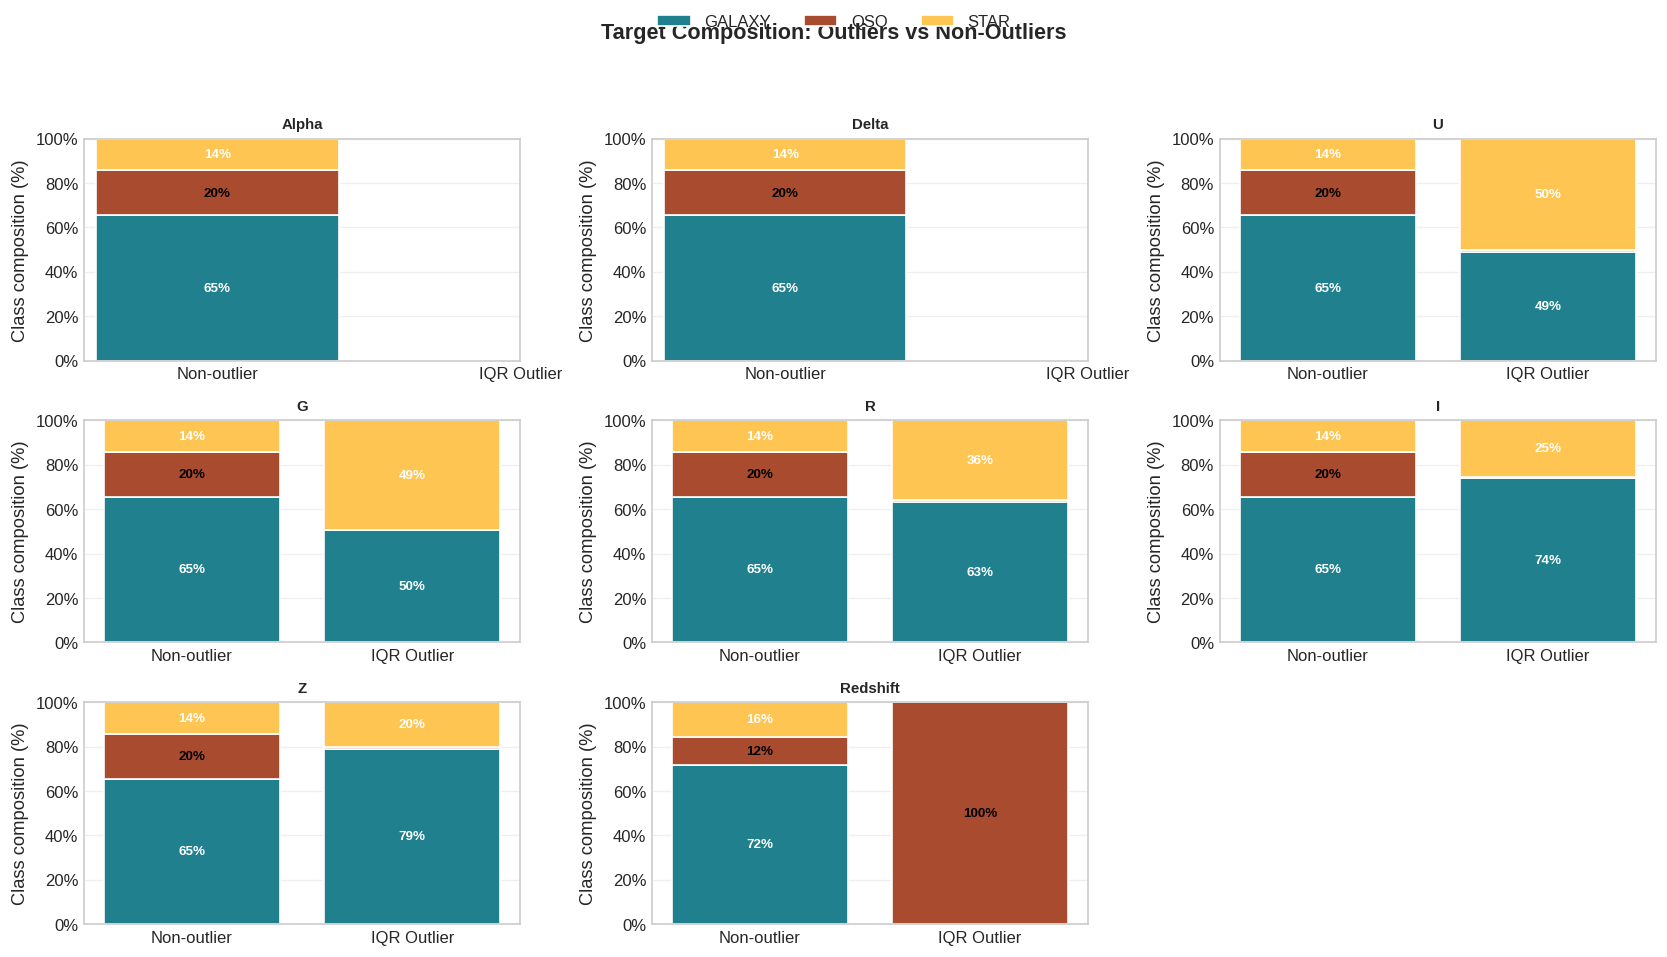

In [17]:

target_col = features.target
target_levels = df_train[target_col].cat.categories.tolist()

fig, axes = plt.subplots(3, 3, figsize=(14, 8))
axes = axes.ravel()

for idx, feat in enumerate(nums):
    ax = axes[idx]

    plot_df = df_train[[feat, target_col]].dropna().copy()
    iqr_mask = iqr_outliers(plot_df[feat])

    grp_non = plot_df.loc[~iqr_mask, target_col]
    grp_out = plot_df.loc[iqr_mask, target_col]

    # Class proportions (%)
    non_dist = (
        grp_non.value_counts(normalize=True)
        .reindex(target_levels, fill_value=0)
        * 100
    )
    out_dist = (
        grp_out.value_counts(normalize=True)
        .reindex(target_levels, fill_value=0)
        * 100
    )

    x = np.arange(2)
    labels = ['Non-outlier', 'IQR Outlier']
    bottoms = np.zeros(2)

    for i, cls in enumerate(target_levels):
        vals = [non_dist.loc[cls], out_dist.loc[cls]]
        bars = ax.bar(
            x,
            vals,
            bottom=bottoms,
            color=PALETTE_BIN[i],
            edgecolor='white',
            label=str(cls) if idx == 0 else None,
        )

        # Optional segment labels only if large enough
        for j, v in enumerate(vals):
            if v >= 8:
                ax.text(
                    x[j],
                    bottoms[j] + v / 2,
                    f'{v:.0f}%',
                    ha='center',
                    va='center',
                    fontsize=8,
                    color='white' if i != 1 else 'black',
                    fontweight='bold',
                )

        bottoms += vals

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=0)
    ax.set_ylim(0, 100)
    ax.set_title(feat.replace('_', ' ').title(), fontweight='bold', fontsize=9)
    ax.set_ylabel('Class composition (%)')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    ax.grid(axis='y', alpha=0.3)

# Hide unused axes if needed
for j in range(len(nums), len(axes)):
    axes[j].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(target_levels), frameon=False)

fig.suptitle('Target Composition: Outliers vs Non-Outliers', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

## 10. Key Findings